# Semana 6 - Modelo logístico

O termo cifose refere-se a uma grave curvatura protuberante da coluna vertebral que necessita de cirurgia corretiva. Um estudo realizado para determinar os fatores de risco da cifose relatou as idades a seguir (meses) para 40 indivíduos no momento da cirurgia; os primeiros 18 indivíduos tiveram cifose e os 22 restantes, não.


|Cifose    |12|15|42|52|59|73|82|91|96|105|114|120|121|128|130|139|139|157|   |   |   |
|----------|--|--|--|--|--|--|--|--|--|---|---|---|---|---|---|---|---|---|---|---|---|
|Sem Cifose|1 |1 |2 |8 |11|18|22|31|37|61 |72 |81 |97 |112|118|127|131|140|151|159|177|


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
import seaborn as sns
from statsmodels.graphics.gofplots import ProbPlot
plt.style.use('seaborn-v0_8')
plt.rc('axes', titlesize=10)

In [3]:
lstx = (12,15,42,52,59,73,82,91,96,105,114,120,121,128,130,
        139,139,157,1,1,2,8,11,18,22,31,37,61,72,81,97,112,
        118,127,131,140,151,159,177,206)
lsty= (1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,
       0,0,0,0,0,0,0,0,0,0,0,0,0,0)
# Construir o DataFrame e nomear as colunas
df = pd.DataFrame(list(zip(lstx, lsty)),
               columns =["x","y"])
x=df['x']
y=df['y']
df.head()

,x,y
0,12,1
1,15,1
2,42,1
3,52,1
4,59,1


In [4]:
#adicionar uma constante preditora
x = sm.add_constant(x)
# Construir o modelo e ajustar os dados
model = sm.Logit(y, x).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.681303
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                   40
Model:                          Logit   Df Residuals:                       38
Method:                           MLE   Df Model:                            1
Date:                Tue, 24 Mar 2026   Pseudo R-squ.:                0.009934
Time:                        17:49:22   Log-Likelihood:                -27.252
converged:                       True   LL-Null:                       -27.526
Covariance Type:            nonrobust   LLR p-value:                    0.4596
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.5727      0.602     -0.951      0.342      -1.753       0.608
x              0.0043      0.

In [5]:
#b0 e b1
b=model.params
print(model.params)

const   -0.572693
x        0.004296
dtype: float64


Text(0, 0.5, 'p(x) Com ou sem Cifose')

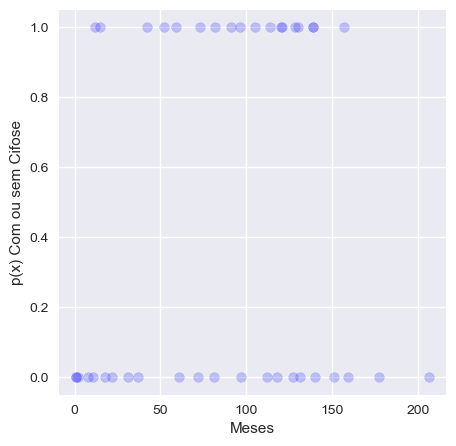

In [6]:
x=df['x']
plt.figure(figsize=(5, 5))
ax = plt.axes()
ax.scatter(x, y, color='b', alpha=0.20)
ax.set_xlabel('Meses')
ax.set_ylabel('p(x) Com ou sem Cifose')


In [7]:
#usar a tabela tstudent
from scipy.stats import t
alpha = 0.05  # nível de signif.= 5% 
df = len(x) - 2 # graus de liberdade (Número de amostras menos dois)                                     
#
v = t.ppf(1 - alpha/2, df) 
tcrit=v
print(f'tcrit=: {v}') 

tcrit=: 2.0243941639119694


In [9]:
#z: estatística de teste 
zt=model.tvalues
zt


const   -0.950694
x        0.734403
dtype: float64

In [10]:
ztb1=zt.x
ztb1

np.float64(0.7344029072729139)

In [11]:
#usar a tabela tstudent
from scipy.stats import t
#calculate p-value  TWO TAILED
p_val= (1-t.cdf(x=abs(ztb1), df=len(x))) * 2
p_val

np.float64(0.46698681622739535)